# Example of cut and flow analysis with HydroRoot

>- In the following there are successive cells with code lines to run and some explanations.
>- Cells with code lines have a number at their top left corner
>- Run the cells with code lines with Ctrl+Enter

## First: some needed code
- to indicate where are the library files of HydroRoot
- to display inline plots in the notebook

In [1]:
# to display inline plots in the notebook
%matplotlib inline
%gui qt5
from openalea.hydroroot.display import plot

QApplication: invalid style override 'kvantum' passed, ignoring it.
	Available styles: Windows, Fusion


## Before running the script

- prepare the input yaml file
- add the experimental data point to the comma separated csv file data/cnf_data.csv

### Yaml file:
It contains different input categories that are explained in the example hydroroot/example/parameters_Ctr-3P2.yml.
>modify and duplicate the file

### the cnf_data file:
>Download *data/maize_cnf_data.csv*, add the data and upload it back

csv file containing cut and flow:

**mendatory columns**:
- arch: name of the architecture file without extension. The file given in 'input_file' of the yaml file
- dP_Mpa: column with the working cut and flow pressure
- J0, ..., Jn: columns containing the flux values, 1st for the full root, then 1st cut, 2d cut, etc.
- lcut1, ...., lcutn: columns containing the maximum length to the base after each cut, 1st cut, 2d cut, etc. (not length for full root)

**optional columns**
- last columns **used only if dP is not constant**:
    - dP0, dP1,.., dPn: containing the working pressure of each steps: full root, 1st cut, 2d cut, etc.
    
**Example**

|arch|dP_Mpa|J0|J1|J2|J3|J4|J5|J6|J7|J8|J9|lcut1|lcut2|lcut3|lcut4|lcut5|lcut6|lcut7|lcut8|lcut9|
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
|Exp03_P2|0.2|0.1|0.11|0.1|0.1|0.12|0.18|||||0.37|0.3|0.25|0.2|0.14|||||
|Exp05_P13|0.3|0.01|0.01|0.01|0.02|0.01|0.02|||||0.26|0.22|0.18|0.14|0.11|||||

## Run the script: direct simulation
- argument '-o': name of the output csv file

Simulation runs:  1
#############################
**********************
optimization finished
**********************
exp06-k8r5.txt 0.1328 226.73553091735633 1.2284000000000002 0.0018125398394536181 0.04321888246601869
exp06-k8r5.txt 0.095569919 226.73553091735633 1.191 0.001691519407252023 0.04768050403651731
exp06-k8r5.txt 0.074728589 226.73553091735633 1.1617 0.0016134871152054585 0.051275472014505656
exp06-k8r5.txt 0.057671275 226.73553091735633 0.9129 0.0012657539947327034 0.05655222335952618


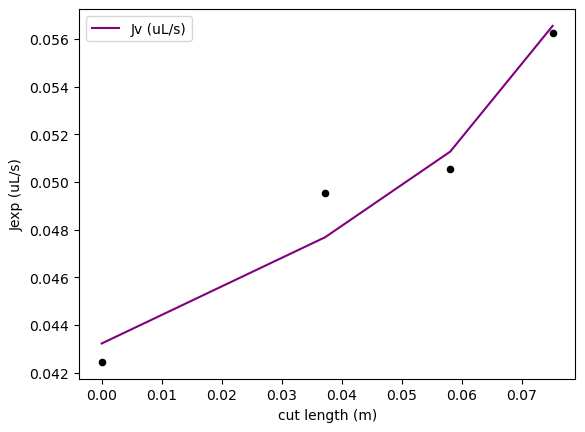

running time is  0.9299428462982178


<Figure size 640x480 with 0 Axes>

In [3]:
%run adjustment_K_and_k.py parameters-exp06-k8r5.yml -o results.csv

## Display architecture
Options:
- cut='tot' is the full root, then cut is the cut length
- prop: property to display
- perspective: activate the zoom
- azimut: axial rotation
- elevation: rotation with the root base as center of rotation
- line_width: lines width

In [5]:
plot_architecture() # function defined in adjustment_K_and_k.py

interactive(children=(Dropdown(description='cut', options=('tot', '0.095569919', '0.074728589', '0.057671275')…

## Run adjustment
- adjust the radial and axial conductance
- argument:
    - '-op': indicate to run optimization
    - '-o': name of the output csv file
- running time is around 30 s on a core i7

Simulation runs:  1
#############################
finished minimize ax, ar [0.95327494 1.10301222]
**********************************
Simu,  256.7481544148724 1.1964969292640568e-05 247.73056891791964 dk0 =  81.31684819485228 dKx =  4.590669408153681e-05
Simu,  247.73056891791964 1.0349998972450451e-05 239.19404023464114 dk0 =  72.87232196043664 dKx =  7.02608569170972e-07
Simu,  239.19404023464114 4.685138717922038e-06 237.5079186108405 dk0 =  2.8430061302480754 dKx =  6.680900441147372e-06
Simu,  237.5079186108405 4.68431549691579e-06 237.3050605519989 dk0 =  0.0411513920369817 dKx =  2.5926197986334296e-13
Simu,  237.3050605519989 4.683507223131296e-06 237.10427677502736 dk0 =  0.040314125094960296 dKx =  2.585487867760738e-13
Simu,  237.10427677502736 4.6827133979000685e-06 236.90556229135626 dk0 =  0.03948744602067059 dKx =  2.579749491722839e-13
Simu,  236.90556229135626 4.6819338517996305e-06 236.70900253870747 dk0 =  0.038635736361355644 dKx =  2.5733497547500364e-13
Simu,  236

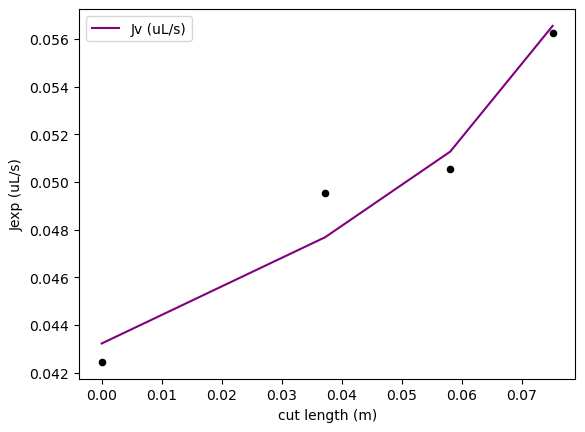

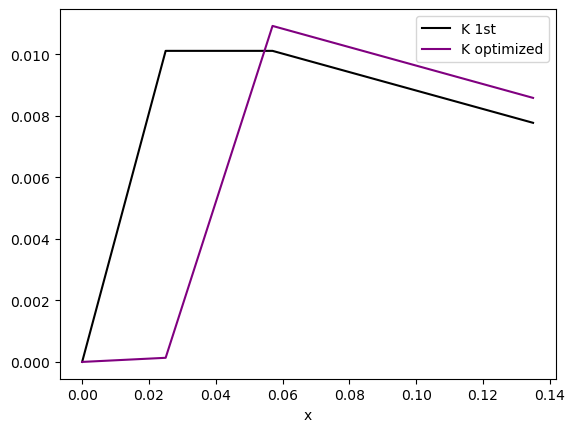

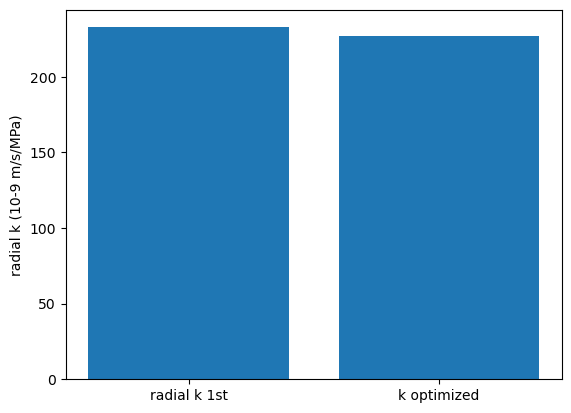

running time is  668.0700521469116


<Figure size 640x480 with 0 Axes>

In [7]:
%run adjustment_K_and_k.py parameters-exp06-k8r5.yml -op -o results.csv

In [5]:
plot_architecture()

interactive(children=(Dropdown(description='cut', options=('tot', '0.095569919', '0.074728589', '0.057671275')…

In [4]:
plot(g_cut['tot'],prop_cmap='J_out') # 'J_out' : xylem flux, 'psi_in' : xylem pressure, 'j' : radial flux